# Rising Main Connectivity & Catchment Strip Builder

Builds connected "strips" of sewer rising main, traced outward from each start
point (pump station), and reports the total length and source catchment of each.

### How it works

- The mains are **split at pump-station points** first, so a pump station that
  sits part-way along a run becomes a real node. This lets a strip be split
  where a second pump station falls mid-run.
- Connectivity is built by **clustering segment ends within a tolerance** into
  shared nodes. No geometry is moved, so every output keeps the **original
  geometry** (no snapped/Integrated geometry, no Maximo re-join needed).
- Strips are traced pipe-to-pipe but never *through* a pump-station node, so
  mains sharing a start point - or meeting at a mid-run pump station - stay
  separate.
- Each segment is tagged with `GROUP_ID`, total strip length, source catchment,
  start-point id and start/end QA flags, then exported as a shapefile + CSV.
- A dissolved layer merges the **original** geometries per strip, with the
  strip's total length.

Run the cells top to bottom in an ArcGIS Pro Python notebook.

### Known limitations
- Strips with no matched start node will get a blank catchment, since there's no start point to read from.

### Future improvements
- Sometimes the topology output is slightly different to the input, the cleanest way would be to have a table and join this to the existing geometry. This can be done right at the end.
- The catchment should be identified from the SPS or STP at the beginning of the segment. Currently the code uses the suburb on the first pipe as a placeholder for this catchment attribute.
- Function commenting/arguments fleshed out more with params/returns.

### Next steps
- Export CSV after removing small segments contained within site polygon. Cannot just do within as some rising mains skirt around the edge of the facility polygon but add significant length (50m+). Onces smaller are filtered.
- Add code to add new feature layers to map workspace before running, as they need to be loaded to do the selection and remove.
- Remove SPS Site string from SRC_CATCH, constant value and to allign with SCADA
- Remove Private SPS
- Do calculations without removed values. Currently they're removed from merged but not from calculation.

In [26]:
import os
import csv
from collections import defaultdict
from dataclasses import dataclass, field as dc_field
from typing import Dict, List, Optional, Tuple, Set

import math
import arcpy

In [27]:
### CONFIG ### 
# Edit these to match paths. Currently shows local copies from ArcGIS Online.

@dataclass
class Config:
    ## General
    target_epsg: int = 7856 # GDA2020 / MGA Zone 56
    project_folder: str = r"c:\ArcGIS Pro Projects\050_septic_rising_mains\050_septic_rising_mains"
    gdb_name: str = "utility_network_inputs.gdb"
    workspace: str = os.path.join(project_folder, gdb_name)
    
    ## Input feature classes. These have been manually extracted and preprocessed. 
    
    # Pressure mains, extracted from ArcGIS Pro
    rising_mains: str = os.path.join(workspace, "Sewer_Pressure_Main")
    # Maintenance holes and closed valves, main endpoints.
    manholes: str = os.path.join(workspace, "Sewer_System_Valve_closed") #"un_manholes_and_closed_valves")
    # Pump stations and STPs, main startpoints. Also used as a break in the mains.
    start_nodes: str = os.path.join(workspace, "Site_SPS_Only") # Use Site Polygon that intersects the linestring.
    site_sps_only: str = os.path.join(workspace, "Site_SPS_Only") # Testing removing from calculations 

    ## Output paths.
    out_shp: str = os.path.join(project_folder, "rising_main_strips.shp")
    out_csv: str = os.path.join(project_folder, "rising_main_strips.csv")
    # Dissolved based on GROUP_ID.
    out_merged: str = os.path.join(workspace, "rising_main_strips_merged")
    
    # Important fields in the rising mains feature class. Taken from AGOL.
    retain_fields: List[str] = dc_field(default_factory=lambda: ["NominalDiameter", "Material"])
    # Maximo ID at asset level.
    maximo_field: str = "MXASSETNUM"
    # ObjectID used as uID for network analysis.
    start_id_field: str = "OBJECTID"
    # Catchment attribute from start node, rather than pipe catchment field.
    start_catch_field: str = "SiteDescription" #StructureName for points, Site for polygons

    ## Snapping tolerances (metres when data is projected via target_epsg)
    # Ends within this distance are treated as one node.
    connect_tolerance:  float = 0.5
    # How close a node must sit to a manhole.
    endpoint_tolerance: float = 1
    # Floating-point tolerance, not for searching. Coordinate rounding but should be touching.
    site_touch_eps: float = 0.05
    # Keep small: above the largest genuine connection gap, well below parallel-main spacing.
    node_tolerance: float = 0.1
    # How far a pump can sit from a main and still label its catchment (metres).
    # Generous on purpose as it's not used for connectivity.
    catch_search_dist: float = 25.0

    ## Other
    # True only if manholes are strictly terminal. Full manhole list so kept as F.
    treat_manholes_as_barriers: bool = True #False 
    # Flag whether each strip touches a PS and a MH.
    validate_endpoints: bool = True 

    ## Field names in outputs. Made compatable with shapefile field lengths.
    length_field: str = "SEG_LEN_M"
    group_id_field: str = "GROUP_ID"
    group_len_field: str = "GRP_LEN_M"
    group_catch_field: str = "SRC_CATCH"
    start_id_field_out: str = "START_ID"
    all_starts_field: str = "ALL_SPS" # Used to capture multiple SPS values in a single catchment.
    start_flag_field: str = "STARTS_Z"
    end_flag_field: str = "ENDS_MH"

    @property
    def keep_fields(self) -> List[str]:
        #return list(dict.fromkeys(self.retain_fields + [self.catchment_field, self.maximo_field]))
        return list(dict.fromkeys(self.retain_fields + [self.maximo_field]))

    @property
    def work_raw(self) -> str:
        return os.path.join(self.workspace, "rising_mains_raw")

    @property
    def working_fc(self) -> str:
        return os.path.join(self.workspace, "rising_mains_work")

    @property
    def work_planar(self) -> str:
        return os.path.join(self.workspace, "rising_planar") # Required for small branches off main trunk being clusered.


In [28]:
## Generic functions
def log(msg: str) -> None:
    """Emit to both the GP message pane and stdout."""
    arcpy.AddMessage(msg)
    print(msg)


class UnionFind:
    """Disjoint-set with path compression."""

    def __init__(self) -> None:
        self.parent: Dict = {}

    def find(self, x):
        self.parent.setdefault(x, x)
        root = x
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[x] != root:           # path compression
            self.parent[x], x = root, self.parent[x]
        return root

    # For combining paths with upstream 
    def union(self, a, b) -> None:
        # Find the root of each side.
        ra, rb = self.find(a), self.find(b)
        # If they aren't already in the same group, then join together.
        if ra != rb:
            # Join by pointing one root at the other.
            self.parent[ra] = rb


def keep_fields_mapping(in_fc: str, keep: List[str]) -> arcpy.FieldMappings:
    """FieldMappings retaining only `keep` (skips any that don't exist)."""
    fms = arcpy.FieldMappings()
    existing = {f.name for f in arcpy.ListFields(in_fc)}
    for fname in keep:
        if fname in existing:
            fm = arcpy.FieldMap()
            fm.addInputField(in_fc, fname)
            fms.addFieldMap(fm)
        else:
            arcpy.AddWarning(f"Field '{fname}' not found in {in_fc} - skipped.")
    return fms


def build_point_index(fc: str, cell: float, id_field: Optional[str] = None, sr=None):
    """Coarse spatial hash of point coords (+ optional id) for fast near-checks."""
    idx = defaultdict(list)
    fields = ["SHAPE@XY"] + ([id_field] if id_field else [])
    with arcpy.da.SearchCursor(fc, fields,spatial_reference = sr) as cur: # Spatial reference required here with differents between AGOL 
        for row in cur:
            xy = row[0]
            if not xy:
                continue
            pid = row[1] if id_field else None
            idx[(int(xy[0] // cell), int(xy[1] // cell))].append((xy[0], xy[1], pid))
    return idx

#
def nearest_id(pt: Tuple[float, float], idx, cell: float, tol: float):
    """Id of the nearest indexed point within `tol`, else None."""
    x, y = pt
    cx, cy = int(x // cell), int(y // cell)
    best_id, best_d2 = None, tol * tol
    for i in (cx - 1, cx, cx + 1):
        for j in (cy - 1, cy, cy + 1):
            for (px, py, pid) in idx.get((i, j), ()):
                d2 = (px - x) ** 2 + (py - y) ** 2
                if d2 <= best_d2:
                    best_id, best_d2 = pid, d2
    return best_id

def match_nodes_to_polygons(node_xy, fc, id_field, eps, sr=None):
    """Map each node id to the id of the site polygon it sits inside, or on the
    boundary of (within floating tolerance), not nearest-distance."""
    polys = []
    with arcpy.da.SearchCursor(fc, ["SHAPE@", id_field], spatial_reference=sr) as cur:
        for shp, pid in cur:
            if shp:
                polys.append((shp, shp.extent, pid))

    matches = {}
    for nid, (x, y) in node_xy.items():
        pt = arcpy.PointGeometry(arcpy.Point(x, y), sr)
        for shp, ext, pid in polys:
            if not (ext.XMin - eps <= x <= ext.XMax + eps and
                    ext.YMin - eps <= y <= ext.YMax + eps):
                continue                                  # extent reject first
            if shp.contains(pt) or shp.distanceTo(pt) <= eps:
                matches[nid] = pid
                break
    return matches

# Map each node id to the nearest point within tolerance.
def match_nodes_to_points(node_xy, fc, id_field, tol, sr=None):
    """Map each node id to the id of a nearby point feature (within tol)."""
    idx = build_point_index(fc, tol, id_field, sr) # Spatial reference required here.
    return {nid: pid for nid, xy in node_xy.items()
            if (pid := nearest_id(xy, idx, tol, tol)) is not None}
# Map each pump t
def match_pumps_to_segments(cfg, dist):
    """{pump_id: (seg_oid, dist)} - nearest segment within `dist`, point-to-line.
    Pass dist=None for global nearest (no cap)."""
    chk = "in_memory/pump_seg_match"
    if arcpy.Exists(chk):
        arcpy.management.Delete(chk)
    arcpy.management.CopyFeatures(cfg.start_nodes, chk)
    radius = f"{dist} Meters" if dist else ""        # "" = no distance cap
    arcpy.analysis.Near(chk, cfg.working_fc, search_radius=radius, method="PLANAR")
    pump_seg = {}
    with arcpy.da.SearchCursor(chk, [cfg.start_id_field, "NEAR_FID", "NEAR_DIST"]) as cur:
        for pid, fid, d in cur:
            if fid is not None and fid >= 0:
                pump_seg[pid] = (fid, d if d is not None else 0.0)
    arcpy.management.Delete(chk)
    return pump_seg


def build_topology(seg_geo: Dict[int, Tuple[Tuple[float, float], Tuple[float, float]]],
                   tol: float):
    """Cluster segment ends within `tol` into shared nodes (no geometry moved).

    Returns (node_xy, seg_node_ids):
      node_xy      = {node_id: (x, y)}              representative coord per node
      seg_node_ids = {oid: (start_node, end_node)}  the two node ids per segment
    """
    pts, ref = [], []                                  # parallel: coord, (oid, end)
    for oid, (a, b) in seg_geo.items():
        pts.append(a); ref.append((oid, 0))
        pts.append(b); ref.append((oid, 1))

    cell = tol if tol > 0 else 1e-6
    grid = defaultdict(list)
    for i, (x, y) in enumerate(pts):
        grid[(int(x // cell), int(y // cell))].append(i)

    uf = UnionFind()
    t2 = tol * tol
    for i, (x, y) in enumerate(pts):
        gx, gy = int(x // cell), int(y // cell)
        for a in (gx - 1, gx, gx + 1):
            for b in (gy - 1, gy, gy + 1):
                for j in grid.get((a, b), ()):
                    if j > i:
                        xj, yj = pts[j]
                        if (xj - x) ** 2 + (yj - y) ** 2 <= t2:
                            uf.union(i, j)

    root_to_nid, node_pts, end_node, nxt = {}, defaultdict(list), {}, 0
    for i, (x, y) in enumerate(pts):
        r = uf.find(i)
        if r not in root_to_nid:
            root_to_nid[r] = nxt; nxt += 1
        nid = root_to_nid[r]
        end_node[ref[i]] = nid
        node_pts[nid].append((x, y))

    node_xy = {nid: (sum(p[0] for p in ps) / len(ps), sum(p[1] for p in ps) / len(ps))
               for nid, ps in node_pts.items()}
    seg_node_ids = {oid: (end_node[(oid, 0)], end_node[(oid, 1)]) for oid in seg_geo}

    # Real coincident junction shouldn't span more than tol assigned at the start tol across all its member endpoints. 
    # A higher value means union near-miss pairs together, issue with crossover mains and unfortunate vertex spots.
    for nid, ps in node_pts.items():
        if len(ps) > 1:
            xs, ys = [p[0] for p in ps], [p[1] for p in ps]
            span = math.hypot(max(xs) - min(xs), max(ys) - min(ys))
            if span > tol * 1.5:
                arcpy.AddWarning(
                    f"Node {nid}: {len(ps)} endpoints span {span:.2f} m (tol={tol} m) "
                    f"- likely a chained false merge, check this location manually.")

    return node_xy, seg_node_ids

def remove_stub_segments(cfg: Config) -> None:
    """Drop short segments that sit wholly inside an SPS site (the leftover
    sliver from splitting mains at the site boundary) before any length or
    volume totals are calculated."""
    log("Removing short in-site stub segments before length calculations...")
    lyr = "working_fc_lyr"
    if arcpy.Exists(lyr):
        arcpy.management.Delete(lyr)
    arcpy.management.MakeFeatureLayer(cfg.working_fc, lyr)

    arcpy.management.SelectLayerByLocation(
        in_layer=lyr,
        overlap_type="WITHIN",
        select_features=cfg.site_sps_only,
        selection_type="NEW_SELECTION",
    )
    arcpy.management.SelectLayerByAttribute(
        in_layer_or_view=lyr,
        selection_type="SUBSET_SELECTION",
        where_clause="Shape_Length <= 50",
    )
    n = int(arcpy.management.GetCount(lyr)[0])
    if n:
        arcpy.management.DeleteFeatures(lyr)
        log(f"  -> removed {n} stub segment(s).")
    arcpy.management.Delete(lyr)


In [29]:
## Pipeline functions
def prepare_working_copy(cfg: Config) -> None:
    """Trimmed working copy, then split the mains at pump stations so a
    structure part-way along a run becomes a node (splitting the strip there).
    No vertices are moved, so geometry stays original."""
    if not arcpy.Exists(cfg.workspace):
        arcpy.management.CreateFileGDB(os.path.dirname(cfg.workspace), os.path.basename(cfg.workspace))

    log("Exporting trimmed working copy...")
    arcpy.conversion.ExportFeatures(
        cfg.rising_mains, cfg.work_raw,
        field_mapping=keep_fields_mapping(cfg.rising_mains, cfg.keep_fields),
    )
    arcpy.management.RepairGeometry(cfg.work_raw, delete_null="DELETE_NULL")

    #log("Planarising mains (splitting at all junctions)...") # Property for clustering branches used here.
    #arcpy.management.FeatureToLine(
   #     cfg.work_raw, cfg.work_planar, f"{cfg.node_tolerance} Meters", "ATTRIBUTES") #Snapping to node tolerance here.

    ## Trying FeatureVerticiesToPoints over FeatureToLine to remove overlapping but not genuine intersecting pipe
    log("Noding mains at pipe endpoints (true tees only, not crossings/overlaps)...")
    ends = cfg.work_planar + "_ends"
    arcpy.management.FeatureVerticesToPoints(cfg.work_raw, ends, "BOTH_ENDS")
    arcpy.management.SplitLineAtPoint(
        cfg.work_raw, ends, cfg.work_planar, f"{cfg.node_tolerance} Meters")
    arcpy.management.Delete(ends)

    # Add comments here. Adjusted for polygon site.
    log("Splitting mains at site polygon boundaries...")
    site_lines = cfg.workspace + r"\site_boundaries_tmp"
    site_pts   = cfg.workspace + r"\site_touch_pts_tmp"
    arcpy.management.PolygonToLine(cfg.start_nodes, site_lines)
    arcpy.analysis.Intersect([cfg.work_planar, site_lines], site_pts, output_type="POINT")
    radius = f"{cfg.connect_tolerance} Meters"  # Points sit exactly on the line
    arcpy.management.SplitLineAtPoint(cfg.work_planar, site_pts, cfg.working_fc, radius)
    arcpy.management.Delete([site_lines, site_pts])
    
    if cfg.treat_manholes_as_barriers:
        tmp = cfg.working_fc + "_mh"
        arcpy.management.SplitLineAtPoint(cfg.working_fc, cfg.manholes, tmp, radius)
        arcpy.management.Delete(cfg.working_fc)
        arcpy.management.Rename(tmp, cfg.working_fc)


def calculate_length(cfg: Config) -> None:
    """Per-segment planar length in metres (projected CS, e.g. MGA Zone 56)."""
    log("Calculating segment lengths...")
    arcpy.management.AddField(cfg.working_fc, cfg.length_field, "DOUBLE")
    arcpy.management.CalculateGeometryAttributes(
        cfg.working_fc, [[cfg.length_field, "LENGTH"]],
        length_unit="METERS", coordinate_system=arcpy.SpatialReference(cfg.target_epsg),
    )

# Function for calculating volume across segments.
def calculate_pipe_volumes(cfg: Config) -> None:
    """Per-segment diameter, cross-sectional area and internal volume.
    Diameter from NominalDiameter, assumed millimetres -> metres.
    AREA_M2 = pi * r^2 ; VOL_M3 = AREA_M2 * SEG_LEN_M."""
    log("Calculating pipe volumes...")
    diam_f, area_f, vol_f = "DIAM_M", "AREA_M2", "VOL_M3"
    for fname in (diam_f, area_f, vol_f):
        arcpy.management.AddField(cfg.working_fc, fname, "DOUBLE")

    dn_field = "NominalDiameter"   # change here if the diameter field is named differently
    with arcpy.da.UpdateCursor(
            cfg.working_fc, [dn_field, cfg.length_field, diam_f, area_f, vol_f]) as cur:
        for row in cur:
            nd, length = row[0], row[1]
            if nd is None:
                row[2] = row[3] = row[4] = None
            else:
                d = nd / 1000.0                      # mm -> m  (drop /1000 if already in m)
                area = math.pi * (d / 2.0) ** 2
                row[2], row[3], row[4] = d, area, area * (length or 0.0)
            cur.updateRow(row)



def read_segments(cfg: Config):
    """Read each segment's endpoints and length."""
    seg_geo, seg_len = {}, {}
    with arcpy.da.SearchCursor(cfg.working_fc,
                               ["OID@", "SHAPE@", cfg.length_field]) as cur:
        for oid, shp, length in cur:
            if shp is None:
                continue
            fp, lp = shp.firstPoint, shp.lastPoint
            seg_geo[oid] = ((fp.X, fp.Y), (lp.X, lp.Y))
            seg_len[oid] = length if length is not None else shp.getLength("PLANAR", "METERS")
    return seg_geo, seg_len


def trace_strips(seg_node_ids: Dict[int, Tuple[int, int]],
                 barrier_nodes: Set[int],
                 blocked_segs: Optional[Dict[int, Set[int]]] = None) -> Dict[int, int]:
    """Union segments that meet at a node, but never *through* a barrier node
    (pump stations). At a node with `blocked_segs` (closed valves), only the
    valve's own segment is held out - other legs meeting at the same node
    (e.g. a T-junction mainline) still merge with each other. Returns {oid: group_id}."""
    blocked_segs = blocked_segs or {}
    node_segs = defaultdict(list)
    for oid, (a, b) in seg_node_ids.items():
        node_segs[a].append(oid)
        node_segs[b].append(oid)

    uf = UnionFind()
    for nid, segs in node_segs.items():
        if nid in barrier_nodes:
            continue
        free = [s for s in segs if s not in blocked_segs.get(nid, ())]
        for s in free[1:]:
            uf.union(free[0], s)

    roots, group_of_seg, nxt = {}, {}, 1
    for oid in seg_node_ids:
        r = uf.find(oid)
        if r not in roots:
            roots[r] = nxt; nxt += 1
        group_of_seg[oid] = roots[r]
    return group_of_seg

def assign_catchment(seg_node_ids, pump_seg, pump_catch):
    """Catchment follows physical connectivity. Each pump is matched to the segment it
    sits on / nearest within range (point-to-line), and each physical component takes
    the catchment of its CLOSEST pump. The value then applies to every segment in that
    component - trunk and every fork - regardless of strip barriers.

    pump_seg: {pump_id: (seg_oid, dist)} from match_pumps_to_segments.
    """
    node_segs = defaultdict(list)
    for oid, (a, b) in seg_node_ids.items():
        node_segs[a].append(oid)
        node_segs[b].append(oid)

    # Physical components: union everything that shares a node (barriers IGNORED here).
    uf = UnionFind()
    for oid in seg_node_ids:
        uf.find(oid)
    for segs in node_segs.values():
        for s in segs[1:]:
            uf.union(segs[0], s)

    # Each component takes the catchment of its nearest pump.
    comp_best = {}                       # component root -> (distance, catch)
    for pid, (seg_oid, d) in pump_seg.items():
        catch = pump_catch.get(pid)
        if catch in (None, "") or seg_oid not in seg_node_ids:
            continue
        root = uf.find(seg_oid)
        if root not in comp_best or d < comp_best[root][0]:
            comp_best[root] = (d, catch)

    return {oid: comp_best.get(uf.find(oid), (None, ""))[1] for oid in seg_node_ids}

def summarise_groups(seg_node_ids, seg_len, seg_catchment, group_of_seg, start_map, mh_map, pump_catch):
    """Per-strip total length, catchment, start-point id(s) and endpoint flags."""
    group_len = defaultdict(float)
    group_catch = {}
    group_start_id, group_starts_z, group_ends_mh = {}, defaultdict(int), defaultdict(int)
    group_all_starts = defaultdict(list)

    for oid, (a, b) in seg_node_ids.items():
        gid = group_of_seg[oid]
        group_len[gid] += seg_len[oid]
        if not group_catch.get(gid):
            group_catch[gid] = seg_catchment.get(oid, "")
        for nid in (a, b):
            if nid in start_map:
                group_starts_z[gid] = 1
                sid = start_map[nid]
                group_start_id.setdefault(gid, sid)
                catch_name = pump_catch.get(sid, sid)
                if catch_name not in group_all_starts[gid]:
                    group_all_starts[gid].append(catch_name)
            if nid in mh_map:
                group_ends_mh[gid] = 1
    group_primary_catch = {gid: (group_catch.get(gid) or "") for gid in group_len}
    # Combine
    group_all_starts_str = {gid: "; ".join(str(s) for s in ids)
                             for gid, ids in group_all_starts.items()}
    return (group_len, group_primary_catch, group_start_id, group_starts_z,
            group_ends_mh, group_all_starts_str)

# Add more comments here
def write_attributes(cfg, group_of_seg, group_len, group_catch,
                     group_start_id, group_starts_z, group_ends_mh,
                     group_all_starts) -> None:
    """Add and populate the strip fields on the (original-geometry) working FC."""
    log("Writing strip attributes...")
    new_fields = [(cfg.group_id_field, "LONG"), (cfg.group_len_field, "DOUBLE"),
                  (cfg.group_catch_field, "TEXT"), (cfg.start_id_field_out, "TEXT"),
                  (cfg.all_starts_field, "TEXT")]
    if cfg.validate_endpoints:
        new_fields += [(cfg.start_flag_field, "SHORT"), (cfg.end_flag_field, "SHORT")]
    for fname, ftype in new_fields:
        arcpy.management.AddField(cfg.working_fc, fname, ftype)

    fields = ["OID@", cfg.group_id_field, cfg.group_len_field,
              cfg.group_catch_field, cfg.start_id_field_out, cfg.all_starts_field]
    if cfg.validate_endpoints:
        fields += [cfg.start_flag_field, cfg.end_flag_field]

    with arcpy.da.UpdateCursor(cfg.working_fc, fields) as cur:
        for row in cur:
            gid = group_of_seg.get(row[0])
            if gid is None:
                continue
            row[1] = gid
            row[2] = round(group_len[gid], 3)
            row[3] = str(group_catch[gid])
            sid = group_start_id.get(gid)
            row[4] = "" if sid is None else str(sid)
            row[5] = group_all_starts.get(gid, "")
            if cfg.validate_endpoints:
                row[6] = group_starts_z.get(gid, 0)
                row[7] = group_ends_mh.get(gid, 0)
            cur.updateRow(row)


def export_outputs(cfg: Config) -> None:
    """Per-segment shapefile + CSV (original geometry)."""
    log("Exporting per-segment shapefile + CSV...")
    arcpy.management.CopyFeatures(cfg.working_fc, cfg.out_shp)

    csv_fields = ["OID@"] + cfg.keep_fields + [
        cfg.length_field, "DIAM_M", "AREA_M2", "VOL_M3",
        cfg.group_id_field, cfg.group_len_field,
        cfg.group_catch_field, cfg.start_id_field_out, cfg.all_starts_field,
    ]
    if cfg.validate_endpoints:
        csv_fields += [cfg.start_flag_field, cfg.end_flag_field]

    with open(cfg.out_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["OBJECTID"] + csv_fields[1:])
        with arcpy.da.SearchCursor(cfg.working_fc, csv_fields) as cur:
            writer.writerows(cur)

def merge_strips(cfg: Config) -> None:
    """Dissolve the original geometries by GROUP_ID -> one row per strip,
    carrying the total length, catchment, start id and member-asset list."""
    log("Merging strips (original geometry dissolved by GROUP_ID)...")
    stats = [[cfg.length_field, "SUM"],
             ["VOL_M3", "SUM"],
             [cfg.group_catch_field, "FIRST"],
             [cfg.start_id_field_out, "FIRST"],
             [cfg.all_starts_field, "FIRST"],
             [cfg.maximo_field, "COUNT"],
             [cfg.maximo_field, "CONCATENATE"]]
    arcpy.management.Dissolve(
        cfg.working_fc, cfg.out_merged,
        dissolve_field=[cfg.group_id_field], statistics_fields=stats,
        multi_part="MULTI_PART", unsplit_lines="DISSOLVE_LINES",
        concatenation_separator="; ",
    )
    rename = {f"SUM_{cfg.length_field}": cfg.group_len_field,
              "SUM_VOL_M3": "GRP_VOL_M3",
              f"FIRST_{cfg.group_catch_field}": cfg.group_catch_field,
              f"FIRST_{cfg.start_id_field_out}": cfg.start_id_field_out,
              f"FIRST_{cfg.all_starts_field}": cfg.all_starts_field,
              f"COUNT_{cfg.maximo_field}": "N_SEG",
              f"CONCATENATE_{cfg.maximo_field}": "MX_LIST"}
    have = {f.name for f in arcpy.ListFields(cfg.out_merged)}
    for old, new in rename.items():
        if old in have:
            arcpy.management.AlterField(cfg.out_merged, old, new, new)
    log(f"  Merged -> {cfg.out_merged}")

def match_valves_to_segment_ends(seg_geo, seg_node_ids, fc, tol, sr=None):
    """Map each node touched by a valve to the specific segment id whose end
    is nearest that valve. Other segments sharing the same node are left out of the block, so they
    can still union with each other. Fix for T junction edges prior to node not being grouped in 
    rising main group."""
    idx = defaultdict(list)
    cell = tol if tol > 0 else 1e-6
    for oid, (a, b) in seg_geo.items():
        for end_idx, xy in enumerate((a, b)):
            idx[(int(xy[0] // cell), int(xy[1] // cell))].append((xy[0], xy[1], oid, end_idx))

    blocked = defaultdict(set)
    with arcpy.da.SearchCursor(fc, ["SHAPE@XY"], spatial_reference=sr) as cur:
        for (vx, vy), in cur:
            cx, cy = int(vx // cell), int(vy // cell)
            best_oid, best_end, best_d2 = None, None, tol * tol
            for i in (cx - 1, cx, cx + 1):
                for j in (cy - 1, cy, cy + 1):
                    for (px, py, oid, end_idx) in idx.get((i, j), ()):
                        d2 = (px - vx) ** 2 + (py - vy) ** 2
                        if d2 <= best_d2:
                            best_oid, best_end, best_d2 = oid, end_idx, d2
            if best_oid is not None:
                node_id = seg_node_ids[best_oid][best_end]
                blocked[node_id].add(best_oid)
    return blocked


In [30]:
def main(cfg: Optional[Config] = None) -> None:
    cfg = cfg or Config()
    arcpy.env.overwriteOutput = True
    arcpy.env.addOutputsToMap = False # Avoiding schema locks with data thats open in the map.
    arcpy.env.outputCoordinateSystem = arcpy.SpatialReference(cfg.target_epsg)  # Required step for measuring length, issues without.

    prepare_working_copy(cfg) # Export + split at pump stations
    remove_stub_segments(cfg) # Remove smaller segments
    calculate_length(cfg)
    calculate_pipe_volumes(cfg)

    seg_geo, seg_len = read_segments(cfg)
    node_xy, seg_node_ids = build_topology(seg_geo, cfg.node_tolerance)
    sr = arcpy.SpatialReference(cfg.target_epsg)  # Define locally; don't inherit a stray global.

    # Add comments
    log("Matching nodes to pump stations / closed valves...")
    start_map = match_nodes_to_polygons(node_xy, cfg.start_nodes, cfg.start_id_field, cfg.site_touch_eps, sr)
    if not start_map:
        arcpy.AddWarning("No nodes matched a pump station - check CRS, tolerance and inputs.")
    pump_catch = {pid: catch for pid, catch in arcpy.da.SearchCursor(
    cfg.start_nodes, [cfg.start_id_field, cfg.start_catch_field])}
    
    mh_map = {}
    if cfg.validate_endpoints or cfg.treat_manholes_as_barriers:
        mh_map = match_nodes_to_points(node_xy, cfg.manholes, "OID@", cfg.endpoint_tolerance, sr)

    barrier = set(start_map)   # pump stations only - genuine strip starts, full node barrier

    valve_blocked = {}
    if cfg.treat_manholes_as_barriers:
        valve_blocked = match_valves_to_segment_ends(seg_geo, seg_node_ids, cfg.manholes, cfg.endpoint_tolerance, sr)

    log("Tracing strips...")
    group_of_seg = trace_strips(seg_node_ids, barrier, valve_blocked)

    # Catchment follows physical connectivity, so forks inherit the trunk's pump value
    # even when they trace out as their own strip.
    pump_seg = match_pumps_to_segments(cfg, cfg.endpoint_tolerance)
    seg_catchment = assign_catchment(seg_node_ids, pump_seg, pump_catch)

    (group_len, group_catch, group_start_id,
     group_starts_z, group_ends_mh, group_all_starts) = summarise_groups(
         seg_node_ids, seg_len, seg_catchment, group_of_seg, start_map, mh_map, pump_catch)

    n = len(set(group_of_seg.values()))
    blank = sum(1 for gid in set(group_of_seg.values()) if not group_catch.get(gid))
    log(f"  -> {n} strips from {len(start_map)} matched pump stations.")
    if blank:
        log(f"  -> {blank} strip(s) have no catchment (not physically connected to a "
            f"pump that has a '{cfg.start_catch_field}' value).")


    # Add calculations for SCADA team
    
    write_attributes(cfg, group_of_seg, group_len, group_catch,
                     group_start_id, group_starts_z, group_ends_mh, group_all_starts)
    export_outputs(cfg)
    merge_strips(cfg)

    log("\nDone.")
    log(f"  Segments : {cfg.out_shp}")
    log(f"  CSV      : {cfg.out_csv}")
    log(f"  Merged   : {cfg.out_merged}")
    log(f"  Strips   : {n}")


In [31]:
# Run the whole process
if __name__ == "__main__":
    main()

Exporting trimmed working copy...
Noding mains at pipe endpoints (true tees only, not crossings/overlaps)...
Splitting mains at site polygon boundaries...
Removing short in-site stub segments before length calculations...
  -> removed 6342 stub segment(s).
Calculating segment lengths...
Calculating pipe volumes...
Matching nodes to pump stations / closed valves...
Tracing strips...
  -> 1163 strips from 1106 matched pump stations.
  -> 326 strip(s) have no catchment (not physically connected to a pump that has a 'SiteDescription' value).
Writing strip attributes...
Exporting per-segment shapefile + CSV...
Merging strips (original geometry dissolved by GROUP_ID)...
  Merged -> c:\ArcGIS Pro Projects\050_septic_rising_mains\050_septic_rising_mains\utility_network_inputs.gdb\rising_main_strips_merged

Done.
  Segments : c:\ArcGIS Pro Projects\050_septic_rising_mains\050_septic_rising_mains\rising_main_strips.shp
  CSV      : c:\ArcGIS Pro Projects\050_septic_rising_mains\050_septic_rising


# Need to code adding these layers to the map for the following to work

arcpy.management.SelectLayerByLocation(
    in_layer="rising_main_strips_merged",
    overlap_type="WITHIN",
    select_features="Site_SPS_Only",
    search_distance=None,
    selection_type="NEW_SELECTION",
    invert_spatial_relationship="NOT_INVERT"
)

arcpy.management.SelectLayerByAttribute(
    in_layer_or_view="rising_main_strips_merged",
    selection_type="SUBSET_SELECTION",
    where_clause="Shape_Length <= 50",
    invert_where_clause=None
)

arcpy.management.DeleteFeatures("rising_main_strips_merged")

### Diagrams for markdown ###
Union function logic

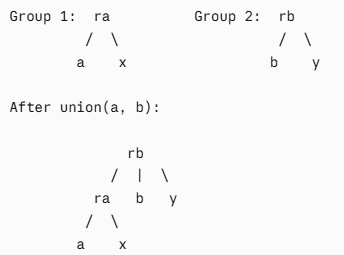


In [72]:
## Sandbox ##

# Checks for crs issues. Non-reprojected data used for repeatability
cfg = Config()
for name, fc in [("working_fc", cfg.working_fc), ("start_nodes", cfg.start_nodes)]:
    sr = arcpy.Describe(fc).spatialReference
    print(name, "->", sr.name, sr.factoryCode)
print("start_nodes count:", int(arcpy.management.GetCount(cfg.start_nodes)[0]))

import itertools
with arcpy.da.SearchCursor(cfg.start_nodes, ["SHAPE@XY"]) as c:
    print("SPS sample XY:", list(itertools.islice((r[0] for r in c), 3)))
with arcpy.da.SearchCursor(cfg.working_fc, ["SHAPE@XY"]) as c:
    print("mains sample XY:", list(itertools.islice((r[0] for r in c), 3)))

working_fc -> GDA2020_MGA_Zone_56 7856
start_nodes -> WGS_1984_Web_Mercator_Auxiliary_Sphere 3857
start_nodes count: 956
SPS sample XY: [(17041680.8156, -3050426.457800001), (17044208.9459, -3049907.1952), (17043468.0193, -3053739.635499999)]
mains sample XY: [(506677.6591157166, 7071102.791986214), (506677.1294, 7071101.410800001), (506675.7345000002, 7071100.2124499995)]


In [73]:
## Debugging branching issuecfg = Config()
target_names = ["SPS-BUD073"] #SPS Structure name
chk = "in_memory/ps_chk"
arcpy.management.CopyFeatures(cfg.start_nodes, chk)
arcpy.analysis.Near(chk, cfg.working_fc, method="PLANAR")
wanted = set(target_names)
with arcpy.da.SearchCursor(chk, [cfg.start_id_field, cfg.start_catch_field, "NEAR_DIST"]) as cur:
    for pid, catch, d in cur:
        if catch not in wanted:
            continue
        flag = "FAR (> tol)" if (d is None or d > cfg.endpoint_tolerance) else "ok"
        print(f"{catch!r}  id={pid}  nearest main {('-' if d is None else f'{d:.1f} m'):>9}   "
              f"tol={cfg.endpoint_tolerance} m   {flag}")
arcpy.management.Delete(chk)

'SPS-BUD073'  id=311  nearest main     4.7 m   tol=5 m   ok


<Result 'true'>